In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt



plt.rcParams['figure.figsize'] = (10, 4)

In [11]:
import dask
print(dask.__version__)

unknown


In [12]:
import xarray as xr


DATA_PATH = "data/data.grib"

# Open dataset with isobaric levels - this should create isobaricInhPa as a dimension
# if multiple levels exist, or as a coordinate if only one level
ds = xr.open_dataset(
    DATA_PATH,
    engine="cfgrib",
    backend_kwargs={
        "indexpath": "",
        "filter_by_keys": {
            "typeOfLevel": "isobaricInhPa"
        }
    }
)

print(ds.dims)



FrozenMappingWarningOnValuesAccess({'time': 2580, 'latitude': 141, 'longitude': 141})


In [16]:
print("Dimensions:", ds.dims)
print("\nCoordinates:", list(ds.coords))
print("\nData variables:", list(ds.data_vars))
if 'u' in ds.data_vars:
    print("\n'u' variable structure:")
    print("Dimensions:", ds.dims)
    print("Coordinate names:", list(ds.coords))
    print("Data variables:", list(ds.data_vars))


Dimensions: FrozenMappingWarningOnValuesAccess({'time': 2580, 'latitude': 141, 'longitude': 141})

Coordinates: ['number', 'time', 'step', 'isobaricInhPa', 'latitude', 'longitude', 'valid_time']

Data variables: ['u', 'v']

'u' variable structure:
Dimensions: FrozenMappingWarningOnValuesAccess({'time': 2580, 'latitude': 141, 'longitude': 141})
Coordinate names: ['number', 'time', 'step', 'isobaricInhPa', 'latitude', 'longitude', 'valid_time']
Data variables: ['u', 'v']


In [17]:
# Select pressure level
LEVEL = 500

# Try to select the level - handle both cases where isobaricInhPa is a dimension or coordinate
try:
    # First, try if isobaricInhPa is a dimension
    if 'isobaricInhPa' in ds.dims:
        u = ds['u'].sel(isobaricInhPa=LEVEL)
        v = ds['v'].sel(isobaricInhPa=LEVEL)
    else:
        # If it's a coordinate, check the value
        current_level = float(ds.coords['isobaricInhPa'].values)
        if current_level == LEVEL:
            u = ds['u']
            v = ds['v']
        else:
            # Reopen with specific level filter
            ds_level = xr.open_dataset(
                DATA_PATH,
                engine="cfgrib",
                backend_kwargs={
                    "indexpath": "",
                    "filter_by_keys": {
                        "typeOfLevel": "isobaricInhPa",
                        "level": LEVEL
                    }
                }
            )
            u = ds_level['u']
            v = ds_level['v']
except (KeyError, ValueError) as e:
    # If selection fails, try opening with explicit level filter
    print(f"Selection failed: {e}. Trying to open with level filter...")
    ds_level = xr.open_dataset(
        DATA_PATH,
        engine="cfgrib",
        backend_kwargs={
            "indexpath": "",
            "filter_by_keys": {
                "typeOfLevel": "isobaricInhPa",
                "level": LEVEL
            }
        }
    )
    u = ds_level['u']
    v = ds_level['v']

# Ensure latitude is ascending
u = u.sortby('latitude')
v = v.sortby('latitude')


In [18]:
t = 0
u_t = u.isel(time=t)
v_t = v.isel(time=t)


print(u_t.shape)

(141, 141)


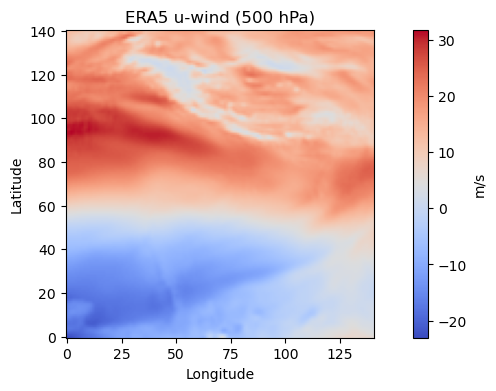

In [19]:
plt.imshow(u_t, cmap='coolwarm', origin='lower')
plt.colorbar(label='m/s')
plt.title('ERA5 u-wind (500 hPa)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

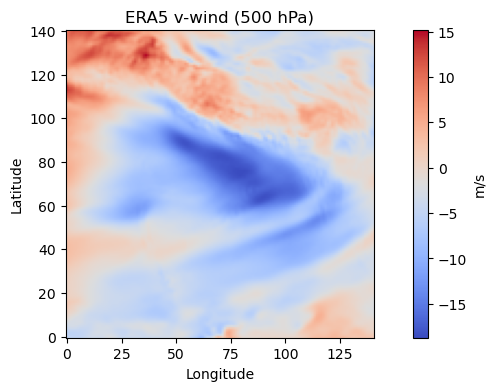

In [20]:
plt.imshow(v_t, cmap='coolwarm', origin='lower')
plt.colorbar(label='m/s')
plt.title('ERA5 v-wind (500 hPa)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [21]:
print("Time steps:", u.time.size)
print("Latitude grid:", u.latitude.size)
print("Longitude grid:", u.longitude.size)

Time steps: 2580
Latitude grid: 141
Longitude grid: 141
